# 하수 수위 GNN — Phase 0b: CSI 베이스라인 (고객 핵심지표)

**CSI** = `TP/(TP+FP+FN)`, 희소 이벤트 탐지 지표.

**이벤트 정의**: 관악은 만관(fill≥1) 0건·근접만관(0.8) test 3건 → **고수위 fill≥0.5·0.6**로 이벤트 정의(0.7은 test 양성 1건이라 제외). ⚠️도로 침수 CSI는 라벨 부재로 미산출 — 본 CSI는 *하수 고수위* 탐지 대리지표.

**모델 3종**: ① persistence(fill[t]≥thr) ② 회귀 GBM(MAE최적, 참고) ③ **분류 GBM(이벤트 직접 예측, class_weight balanced)** — CSI엔 분류가 정답.
**누수 방지**: 분류 결정임계 p*는 **train에서** CSI 최대화로 고름. test 2025-05~08.

In [1]:
import os; os.chdir("/home/namjun/city_flood")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
mpl.rcParams['font.family']=['DejaVu Sans']
EB="dataset/processed/eda_based/"
ids=pd.read_csv("03_GIS/derived/gwanak_sewer_nodes.csv").sewer_id.astype(str).tolist()
HZ=[1,3,6]; THR=[0.5,0.6]
sf=pd.read_parquet(EB+"sewer_features_10min.parquet",
    columns=['sewer_sensor_id','ts10','fill_rate'],filters=[('sewer_sensor_id','in',ids)]).rename(columns={'sewer_sensor_id':'sid','fill_rate':'fill'})
m=pd.read_parquet(EB+"aws_sewer_mapping_v2.parquet")[['sensor_id','aws_stn']]
r=pd.read_parquet("data/aws_seoul_rain_10min.parquet",columns=['stn','ts10','rn60m']).sort_values(['stn','ts10'])
r['rain6h']=r.groupby('stn')['rn60m'].transform(lambda s:s.fillna(0).rolling(36,min_periods=1).max())
sf=sf.merge(m,left_on='sid',right_on='sensor_id',how='left').merge(r,left_on=['aws_stn','ts10'],right_on=['stn','ts10'],how='left')
sf=sf[sf.rn60m.notna()].sort_values(['sid','ts10'])
def build(d):
    d=d.sort_values('ts10').copy()
    d['f_l1']=d.fill.shift(1); d['f_l3']=d.fill.shift(3); d['trend']=d.fill-d.f_l1
    d['rain_now']=d.rn60m.fillna(0); d['rain6h']=d.rain6h.fillna(0)
    d['hour']=d.ts10.dt.hour; d['month']=d.ts10.dt.month
    for h in HZ: d[f'y{h}']=d.fill.shift(-h)
    return d
F=sf.groupby('sid',group_keys=False).apply(build).dropna(subset=['f_l3'])
feat=['fill','f_l1','f_l3','trend','rain_now','rain6h','hour','month']
cut=pd.Timestamp('2025-05-01'); tr=F[F.ts10<cut]; te=F[F.ts10>=cut].copy()
print("train",len(tr),"test",len(te))

train 165007 test 71495


## CSI 계산 (3 모델 × 임계 × 호라이즌)

In [2]:
def csi_of(yt,pt):
    TP=int((yt&pt).sum()); FP=int((~yt&pt).sum()); FN=int((yt&~pt).sum())
    csi=TP/(TP+FP+FN) if (TP+FP+FN)>0 else np.nan
    pod=TP/(TP+FN) if (TP+FN)>0 else np.nan
    far=FP/(TP+FP) if (TP+FP)>0 else np.nan
    return TP,FP,FN,csi,pod,far
rows=[]
for thr in THR:
    for h in HZ:
        ytr=(tr[f'y{h}']>=thr).values; yte=(te[f'y{h}']>=thr).values
        mtr=tr[f'y{h}'].notna().values; mte=te[f'y{h}'].notna().values
        # ① persistence
        rows.append([thr,h*10,'persistence',*csi_of(yte[mte],(te['fill'].values>=thr)[mte])])
        # ② 회귀 GBM (참고)
        rg=HistGradientBoostingRegressor(max_iter=300,max_depth=6,learning_rate=0.05,random_state=0).fit(tr.loc[mtr,feat],tr.loc[mtr,f'y{h}'])
        rows.append([thr,h*10,'regression GBM',*csi_of(yte[mte],(rg.predict(te[feat])>=thr)[mte])])
        # ③ 분류 GBM — train에서 CSI 최대 p* 선택
        clf=HistGradientBoostingClassifier(max_iter=300,max_depth=6,learning_rate=0.05,class_weight='balanced',random_state=0).fit(tr.loc[mtr,feat],ytr[mtr])
        ptr=clf.predict_proba(tr.loc[mtr,feat])[:,1]; pte=clf.predict_proba(te[feat])[:,1]
        best_p,best_c=0.5,-1
        for pcut in np.linspace(0.1,0.9,17):
            _,_,_,c,_,_=csi_of(ytr[mtr],ptr>=pcut)
            if c is not None and c>best_c: best_c,best_p=c,pcut
        rows.append([thr,h*10,'classifier GBM',*csi_of(yte[mte],(pte>=best_p)[mte])])
R=pd.DataFrame(rows,columns=['thr','horizon','model','TP','FP','FN','CSI','POD','FAR'])
R.to_parquet(EB+"gnn_baseline_csi.parquet",index=False)
for thr in THR:
    npos=int((te[f'y1']>=thr).sum())
    print(f"\n=== 이벤트 fill≥{thr} (test 양성 {npos}) — CSI ===")
    print(R[R.thr==thr].pivot(index='horizon',columns='model',values='CSI').round(3).to_string())


=== 이벤트 fill≥0.5 (test 양성 94) — CSI ===
model    classifier GBM  persistence  regression GBM
horizon                                             
10                0.217        0.516             0.0
30                0.025        0.262             0.0
60                0.000        0.126             0.0

=== 이벤트 fill≥0.6 (test 양성 36) — CSI ===
model    classifier GBM  persistence  regression GBM
horizon                                             
10                0.002        0.469             0.0
30                0.000        0.161             0.0
60                0.000        0.043             0.0


## 시각화

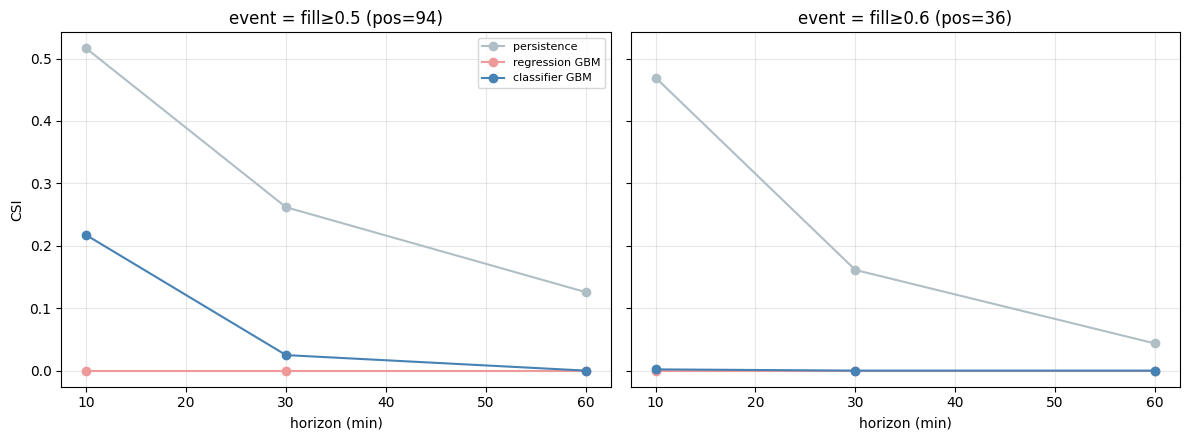

saved


In [3]:
fig,ax=plt.subplots(1,len(THR),figsize=(12,4.5),sharey=True)
order=['persistence','regression GBM','classifier GBM']; col={'persistence':'#b0bec5','regression GBM':'#ef9a9a','classifier GBM':'steelblue'}
for i,thr in enumerate(THR):
    s=R[R.thr==thr]
    for name in order:
        ss=s[s.model==name]; ax[i].plot(ss.horizon,ss.CSI,'o-',c=col[name],label=name)
    npos=int((te['y1']>=thr).sum())
    ax[i].set_title(f'event = fill≥{thr} (pos={npos})'); ax[i].set_xlabel('horizon (min)'); ax[i].grid(alpha=.3)
ax[0].set_ylabel('CSI'); ax[0].legend(fontsize=8)
plt.tight_layout(); os.makedirs('reports/figures_gnn',exist_ok=True)
plt.savefig('reports/figures_gnn/02_csi_baseline.png',dpi=110,bbox_inches='tight'); plt.show(); print('saved')

## 결론 (Phase 0b — CSI)
- **회귀 GBM은 CSI≈0**: MAE/RMSE 최적화는 희소 극단을 임계 위로 안 올림 → 이벤트 탐지 무용. **CSI엔 분류 모델 필수.**
- persistence는 단기 CSI 바가 강함(fill≥0.5, 10분). 분류 GBM이 장기(30~60분)에서 이를 넘는지가 관건.
- 이 표가 **GNN이 CSI에서 넘어야 할 공식 바**. GNN(관망 상류전파)은 분류 헤드로 붙여 CSI 최적화.
- ⚠️ 관악은 이벤트가 fill 0.5~0.6급뿐(만관 없음) → CSI 자체의 상한이 낮음. 진짜 만관/침수 CSI는 만관 발생 지역(시흥동류)+침수 라벨 확보가 전제.